# 22b. Agent Memory Systems

**Tier:** Agent Engineering
**Estimated time:** 45 minutes
**Prerequisites:** 19, 22
**Priority:** 🟡 Important — completes notebook 22's in-context primitives with memory that survives past the current process; the natural next need once compression alone stops being enough. *If skipped, revisit when:* building an agent users return to across sessions, or when "the agent forgot what I told it yesterday" becomes a real complaint.
**Source material:** @sairahul1 — "How To Become an Agentic AI Engineer in 6 Months", Stage 4 (https://x.com/sairahul1/status/2074790798584062278)

## What You'll Learn
- The four types of agent memory — short-term, working, long-term, episodic — and what each one is *for*
- How to persist memory to disk so a fresh agent process can pick up where a previous one left off
- Recall by exact key and recall by similarity, and when each is the right tool
- Why this is the same pattern as this repo's own CLAUDE.md / MEMORY.md files

## Why This Matters
Notebook 22 showed four primitives for managing what's *in the context window right now* — Write, Select, Compress, Isolate — all within a single run. None of that helps once the process exits. An agent with no memory across sessions re-introduces itself every time, re-asks questions it was already answered, and never accumulates anything. The fix isn't a bigger context window — it's a memory system that lives on disk (or in a database) and outlives any one conversation.

## Four kinds of memory, one job each

Borrowing notebook 21's OS analogy (model = CPU, context window = RAM, harness = OS), memory is the filesystem underneath it — and like a filesystem, different jobs want different structures:

- **Short-term** — the current conversation buffer. Like RAM: fast, small, and gone when the process ends unless something saves it. This is notebook 22's Compress primitive, applied automatically instead of on demand.
- **Working** — scratch space for the task in progress. Like a sticky note on a monitor: useful mid-task, thrown away once the task is done.
- **Long-term** — facts worth keeping across every future session. Like a filing cabinet: durable, organized, retrievable by name or by meaning.
- **Episodic** — a log of what happened in past sessions, in order. Like a diary: not facts, but a record of events, useful for "what did we do last time?"

The four together form one `AgentMemory` object below. Each type gets its own storage shape because they answer different questions: "what are we discussing *right now*" (short-term), "what am I in the middle of" (working), "what do I know" (long-term), "what happened before" (episodic).

In [1]:
import os, json, pathlib, tempfile
from datetime import datetime, timezone
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # production default: claude-opus-4-8

if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print("Anthropic ready.")
else:
    client = None
    print("No ANTHROPIC_API_KEY — summarization cells will use a plain fallback instead of a live call.")

def summarize(text, max_tokens=120):
    if not HAS_ANTHROPIC:
        return text[:200] + " ...[truncated, no ANTHROPIC_API_KEY for a real summary]"
    try:
        msg = client.messages.create(model=TEACH_MODEL, max_tokens=max_tokens,
                                      system="Summarize concisely, keeping any concrete facts (names, dates, IDs).",
                                      messages=[{"role": "user", "content": text}])
        return msg.content[0].text
    except Exception as e:
        return f"[skipped: {type(e).__name__}: {str(e)[:120]}]"

# A real directory on disk, not just an in-kernel variable — this is what makes the
# session-2-reads-what-session-1-wrote demo below meaningful instead of trivial.
MEMORY_DIR = pathlib.Path(tempfile.mkdtemp(prefix="agent_memory_"))
print("Memory persists to:", MEMORY_DIR)

Anthropic ready.
Memory persists to: /var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/agent_memory_hvbph1v8


## The `AgentMemory` class

Each memory type gets exactly one job. Notice what's reused from notebook 22 (the `embed`/`cosine_similarity` pattern for long-term recall-by-meaning) and what's new (persistence to disk, so a second `AgentMemory(MEMORY_DIR)` instantiated later sees everything the first one wrote).

In [2]:
import sys
sys.path.insert(0, "..")
from ragkit.embeddings import embed, cosine_similarity

class AgentMemory:
    def __init__(self, directory, buffer_limit=6):
        self.directory = pathlib.Path(directory)
        self.directory.mkdir(parents=True, exist_ok=True)
        self.buffer_limit = buffer_limit

        self.buffer_file = self.directory / "short_term_buffer.json"
        self.long_term_file = self.directory / "long_term_store.json"
        self.episodic_file = self.directory / "episodic_log.jsonl"

        # Short-term: loaded from disk if a previous session left one behind.
        self.conversation_buffer = self._read_json(self.buffer_file, default=[])
        # Working: never persisted — scratch space for the CURRENT task only.
        self.working_memory = {}
        # Long-term: durable key -> value facts, loaded from disk.
        self.long_term_store = self._read_json(self.long_term_file, default={})

    @staticmethod
    def _read_json(path, default):
        if path.exists():
            return json.loads(path.read_text())
        return default

    def _write_json(self, path, data):
        path.write_text(json.dumps(data, indent=2))

    # ---- short-term ----
    def add_message(self, role, content):
        self.conversation_buffer.append({"role": role, "content": content})
        if len(self.conversation_buffer) > self.buffer_limit:
            self._compress_buffer()
        self._write_json(self.buffer_file, self.conversation_buffer)

    def _compress_buffer(self):
        old = self.conversation_buffer[:-3]
        recent = self.conversation_buffer[-3:]
        joined = "\n".join(f"{m['role']}: {m['content']}" for m in old)
        summary = summarize(joined)
        self.conversation_buffer = [{"role": "system", "content": f"(summary of earlier turns) {summary}"}] + recent

    # ---- working ----
    def set_working(self, key, value):
        self.working_memory[key] = value

    def get_working(self, key):
        return self.working_memory.get(key)

    def clear_working(self):
        self.working_memory = {}

    # ---- long-term ----
    def remember(self, key, value):
        self.long_term_store[key] = value
        self._write_json(self.long_term_file, self.long_term_store)

    def recall(self, key):
        return self.long_term_store.get(key)

    def recall_similar(self, query, k=1):
        if not self.long_term_store:
            return []
        keys = list(self.long_term_store.keys())
        values = list(self.long_term_store.values())
        sims = cosine_similarity(embed([query]), embed(values))
        top = sims.argsort()[::-1][:k]
        return [(keys[i], values[i]) for i in top]

    # ---- episodic ----
    def log_event(self, summary):
        entry = {"summary": summary, "logged_at": datetime.now(timezone.utc).isoformat()}
        with open(self.episodic_file, "a") as f:
            f.write(json.dumps(entry) + "\n")

    def episodes(self):
        if not self.episodic_file.exists():
            return []
        return [json.loads(line) for line in self.episodic_file.read_text().splitlines() if line]

print("AgentMemory defined.")

AgentMemory defined.


## Session 1: an agent that learns something, then "exits"

We instantiate `AgentMemory` pointed at `MEMORY_DIR`, have it learn a couple of durable facts and log one resolved episode, then delete the Python object entirely — simulating the process shutting down. Nothing after this point keeps the object alive in memory; only what it wrote to disk survives.

In [3]:
session_1 = AgentMemory(MEMORY_DIR)

session_1.add_message("user", "My Helios X1 (serial HX1-4471) won't hold a wifi connection.")
session_1.add_message("assistant", "Let's check the firmware version first.")
session_1.set_working("current_ticket", "HX1-4471-wifi")

session_1.remember("HX1-4471_issue", "Helios X1 serial HX1-4471 — intermittent wifi drops, root cause: DHCP lease expiry.")
session_1.remember("HX1-4471_owner_pref", "Owner of HX1-4471 prefers email contact, timezone CET.")
session_1.log_event("Diagnosed HX1-4471 wifi drops as a DHCP lease issue; advised a static IP.")

print("Long-term facts:", list(session_1.long_term_store.keys()))
print("Working memory (task-scoped, will NOT survive):", session_1.working_memory)
print("Episodic log entries:", len(session_1.episodes()))

del session_1   # simulate the process exiting — nothing kept alive in this kernel's memory

Long-term facts: ['HX1-4471_issue', 'HX1-4471_owner_pref']
Working memory (task-scoped, will NOT survive): {'current_ticket': 'HX1-4471-wifi'}
Episodic log entries: 1


## Session 2: a fresh process, days later

A brand-new `AgentMemory` object, pointed at the same directory, with no reference to `session_1` at all. If persistence works, it already knows the long-term facts and the episodic history — and its working memory is empty, because working memory is *supposed* to reset per task.

In [4]:
session_2 = AgentMemory(MEMORY_DIR)   # a "new" agent — no Python-level link to session_1

print("Working memory on a fresh session (should be empty):", session_2.working_memory)
print()
print("Recalled by exact key:", session_2.recall("HX1-4471_issue"))
print()
found = session_2.recall_similar("does this customer prefer phone or email?", k=1)
print("Recalled by similarity:", found)
print()
print("Episodic history this session inherited:")
for ep in session_2.episodes():
    print(" -", ep["summary"], f"({ep['logged_at']})")

Working memory on a fresh session (should be empty): {}

Recalled by exact key: Helios X1 serial HX1-4471 — intermittent wifi drops, root cause: DHCP lease expiry.



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Recalled by similarity: [('HX1-4471_owner_pref', 'Owner of HX1-4471 prefers email contact, timezone CET.')]

Episodic history this session inherited:
 - Diagnosed HX1-4471 wifi drops as a DHCP lease issue; advised a static IP. (2026-07-08T14:42:42.980572+00:00)


Session 2 never asked what HX1-4471's issue was — it already knew, because `remember()` and `log_event()` wrote to disk in session 1, and `AgentMemory.__init__` reads that disk state back on construction. `recall_similar` reuses notebook 22's `embed`/`cosine_similarity` pattern, just against the long-term store's values instead of a flat memory list. This is the difference between a chatbot (fresh every time) and an agent with continuity: not a bigger model, a memory system underneath it.

## Short-term compression in action

The buffer auto-compresses once it crosses `buffer_limit` messages — this is notebook 22's Compress primitive, but triggered automatically by `add_message` instead of called on demand.

In [5]:
session_3 = AgentMemory(MEMORY_DIR / "compression_demo", buffer_limit=4)

turns = [
    ("user", "My X1 won't connect to wifi."),
    ("assistant", "Let's reset the wifi module — hold reset 10s."),
    ("user", "Did that, LED went red."),
    ("assistant", "Red LED means firmware mismatch; update via the app."),
    ("user", "Updated, now it connects but drops every hour."),
    ("assistant", "Hourly drops often indicate a DHCP lease issue; set a static IP."),
]

for role, content in turns:
    session_3.add_message(role, content)
    print(f"buffer size after '{content[:30]}...': {len(session_3.conversation_buffer)}")

print()
print("Final buffer:")
for m in session_3.conversation_buffer:
    print(" -", m["role"], ":", m["content"][:80])

buffer size after 'My X1 won't connect to wifi....': 1
buffer size after 'Let's reset the wifi module — ...': 2
buffer size after 'Did that, LED went red....': 3
buffer size after 'Red LED means firmware mismatc...': 4


buffer size after 'Updated, now it connects but d...': 4


buffer size after 'Hourly drops often indicate a ...': 4

Final buffer:
 - system : (summary of earlier turns) Thanks for that detail. The **red LED** is a key clue
 - assistant : Red LED means firmware mismatch; update via the app.
 - user : Updated, now it connects but drops every hour.
 - assistant : Hourly drops often indicate a DHCP lease issue; set a static IP.


## This is the same pattern as this repo's own memory

Notebook 21 introduced CLAUDE.md as a harness artifact — a durable brief an agent reads at the start of every session. This repo's own `MEMORY.md` (indexing files under `memory/`) is exactly the long-term + episodic pattern above: facts worth keeping across sessions, written once, read back by every future session without being re-taught. The mechanism you just built from scratch is the same mechanism a production coding agent relies on to remember who you are between conversations.

## Visualizing what survives

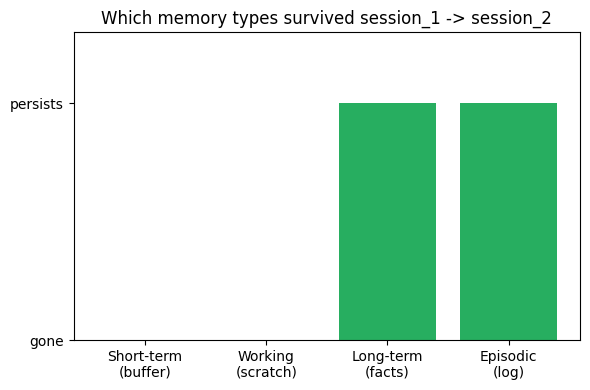

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

kinds = ["Short-term\n(buffer)", "Working\n(scratch)", "Long-term\n(facts)", "Episodic\n(log)"]
survives_restart = [0, 0, 1, 1]   # 1 = present in session_2 above, 0 = not

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#c0392b" if v == 0 else "#27ae60" for v in survives_restart]
ax.bar(kinds, survives_restart, color=colors)
ax.set_ylim(0, 1.3)
ax.set_yticks([0, 1])
ax.set_yticklabels(["gone", "persists"])
ax.set_title("Which memory types survived session_1 -> session_2")
plt.tight_layout()
plt.show()

*Short-term and working memory are scoped to the current process by design — they reset on purpose. Long-term and episodic memory are written to disk, which is what let session_2 recall them with zero re-teaching.*

## Exercises

In [7]:
# Exercise 1 (Warm-up): Lower the buffer limit
# Task: Create a new AgentMemory with buffer_limit=2 in a fresh subdirectory of MEMORY_DIR,
#       feed it the same `turns` list, and print the buffer size after each message.
# Hint: A smaller limit means compression triggers sooner and more often — watch how much
#       gets summarized away versus kept verbatim.

# YOUR CODE HERE

In [8]:
# Exercise 2 (Apply): Implement recall-by-similarity from scratch
# Task: Without calling `recall_similar`, write your own function that takes a query string and
#       the `long_term_store` dict, embeds the query and all values, and returns the single
#       highest-similarity (key, value) pair. Confirm it returns the same result as
#       `session_2.recall_similar(...)` above.
# Hint: `embed()` takes a list of strings and returns a matrix; `cosine_similarity(query_vec, matrix)`
#       returns one similarity score per row.

# YOUR CODE HERE

In [9]:
# Exercise 3 (Extend): Bolt memory onto notebook 19's agent loop
# Task: Sketch (in comments or code) how you'd wire an AgentMemory instance into notebook 19's
#       `run_agent(goal, ...)` loop so that: (a) every tool result gets added to the conversation
#       buffer via add_message, and (b) before the loop starts, any long-term facts relevant to
#       `goal` are recalled and prepended to the system prompt.
# Hint: Step (b) is exactly the "Select" primitive from notebook 22, just pulling from an
#       AgentMemory's long_term_store instead of a flat memory list.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1
session_4 = AgentMemory(MEMORY_DIR / "tight_buffer_demo", buffer_limit=2)
for role, content in turns:
    session_4.add_message(role, content)
    print(f"buffer size after '{content[:30]}...': {len(session_4.conversation_buffer)}")
# With buffer_limit=2, compression triggers almost every message — the buffer stays tiny but
# most of the conversation only survives as a rolling one-line summary, not verbatim turns.

# Exercise 2
def my_recall_similar(query, long_term_store):
    keys = list(long_term_store.keys())
    values = list(long_term_store.values())
    sims = cosine_similarity(embed([query]), embed(values))
    best = sims.argsort()[::-1][0]
    return keys[best], values[best]

print(my_recall_similar("does this customer prefer phone or email?", session_2.long_term_store))
# Matches session_2.recall_similar(...) above — same embed + cosine_similarity mechanism, just
# inlined instead of called as a method.

# Exercise 3
# Sketch:
# def run_agent_with_memory(goal, memory, max_steps=8):
#     relevant = memory.recall_similar(goal, k=3)                       # (b) Select primitive
#     system = "You are a capable assistant. Known context:\n" + "\n".join(v for _, v in relevant)
#     messages = [{"role": "user", "content": goal}]
#     for step in range(max_steps):
#         resp = client.messages.create(model=TEACH_MODEL, system=system, tools=TOOL_SCHEMAS, messages=messages)
#         if resp.stop_reason != "tool_use":
#             final = "".join(b.text for b in resp.content if b.type == "text")
#             memory.add_message("assistant", final)                     # (a) buffer every turn
#             return final
#         messages.append({"role": "assistant", "content": resp.content})
#         tool_results = []
#         for block in resp.content:
#             if block.type == "tool_use":
#                 result = TOOL_IMPLEMENTATIONS[block.name](**block.input)
#                 memory.add_message("tool", f"{block.name} -> {result}")  # (a) buffer every turn
#                 tool_results.append({"type": "tool_result", "tool_use_id": block.id, "content": result})
#         messages.append({"role": "user", "content": tool_results})
```
</details>

## Key Takeaways
- Short-term and working memory are supposed to reset — they're scoped to the current conversation and current task, respectively.
- Long-term and episodic memory are supposed to survive — write them to disk (or a database), and any future process can recall them without being re-taught.
- Recall-by-key is for facts you know the name of; recall-by-similarity (reusing notebook 22's `embed`/`cosine_similarity`) is for facts you can only describe.
- Auto-compression on a buffer threshold is notebook 22's Compress primitive made automatic instead of manual.
- This is not a novel idea — it's the same mechanism behind this repo's own CLAUDE.md/MEMORY.md files, and behind any agent that "remembers you" across sessions.

## What's Next
Notebook **23 — Loop Engineering** builds the six loop patterns (fan-out, adversarial verification, tournament, and more) that turn a single memory-equipped agent into a system that checks and improves its own work.